# Gray-Scott experiments

This notebook runs the C++/CUDA library from Python. It sets parameters, runs CPU/CUDA quick tests, and asks C++ to write a GIF.

In [2]:
from pathlib import Path
import sys

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / "build" / "python"))

import gray_scott

print("Package loaded from:", gray_scott.__file__)

Package loaded from: c:\Users\Adam\Documents\Code\gray-scott\build\python\gray_scott\__init__.py


## Quick backend tests

These use a few steps so CPU and CUDA can be checked quickly.

In [3]:
quick_test = gray_scott.Config()
quick_test.width = 32
quick_test.height = 32
quick_test.steps = 4
quick_test.frame_interval = 2

gray_scott.simulate(quick_test, backend=gray_scott.Backend.cpu)
print("CPU simulation complete")

gray_scott.simulate(quick_test, backend=gray_scott.Backend.cuda)
print("CUDA simulation complete")

CPU simulation complete
CUDA simulation complete


## An interesting run

The defaults use an active feed/kill pair and concentric rings. Increase `steps` for a longer animation.

Saved gray_scott_python.gif


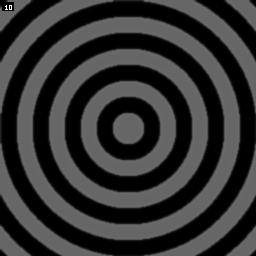

In [4]:
from IPython.display import Image, display


config = gray_scott.Config()
config.width = 256
config.height = 256
config.steps = 500
config.frame_interval = 10
config.initial_condition = gray_scott.InitialCondition.concentric_rings
config.feed = 0.022
config.kill = 0.051

gif_path = "gray_scott_python.gif"
gray_scott.simulate(
    config,
    backend=gray_scott.Backend.cuda,
    gif_path=gif_path,
    fps=10,
    include_step_number=True,
)
print(f"Saved {gif_path}")
display(Image(filename=gif_path))